<a href="https://colab.research.google.com/github/palamankumar688-lgtm/industrial-machine-failure-prediction/blob/main/Industrial_Machine_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/palamankumar688-lgtm/industrial-machine-failure-prediction.git
%cd /content/industrial-machine-failure-prediction

Cloning into 'industrial-machine-failure-prediction'...
/content/industrial-machine-failure-prediction


In [ ]:
!mkdir -p data src reports
!ls

data  reports  src


In [ ]:
%%writefile requirements.text
pandas
numpy
scikit-learn
matplotlib
ucimlrepo

Writing requirements.text


In [ ]:
!pip install -r requirements.text

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [ ]:
print(uploaded.keys())

dict_keys(['ai4i2020.csv'])


In [ ]:
df = pd.read_csv("ai4i2020.csv")

In [ ]:
print("Shape: ",df.shape)
display(df.head())

Shape:  (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
print("Missing value by column:")
print(df.isnull().sum())
print("\nMachine failure counts:")
print(df["Machine failure"].value_counts())
print("\nMachine failure percentages:")
print((df["Machine failure"].value_counts(normalize = True) *100).round(2))

Missing value by column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Machine failure counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure percentages:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


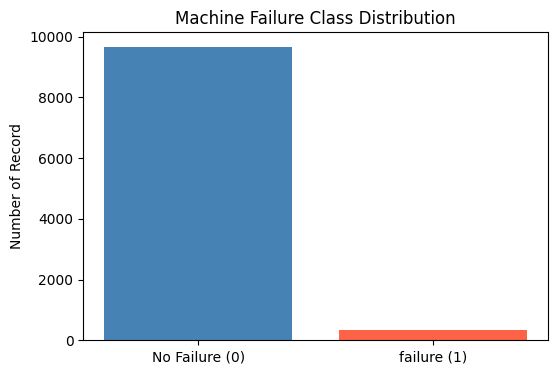

In [ ]:
failure_counts = df["Machine failure"].value_counts().sort_index()
plt.figure(figsize = (6,4))
plt.bar(
    ["No Failure (0)" , "failure (1)"],
    failure_counts.values,
    color=["steelblue"  , "tomato"]
)
plt.title("Machine Failure Class Distribution")
plt.ylabel("Number of Record")
plt.show()

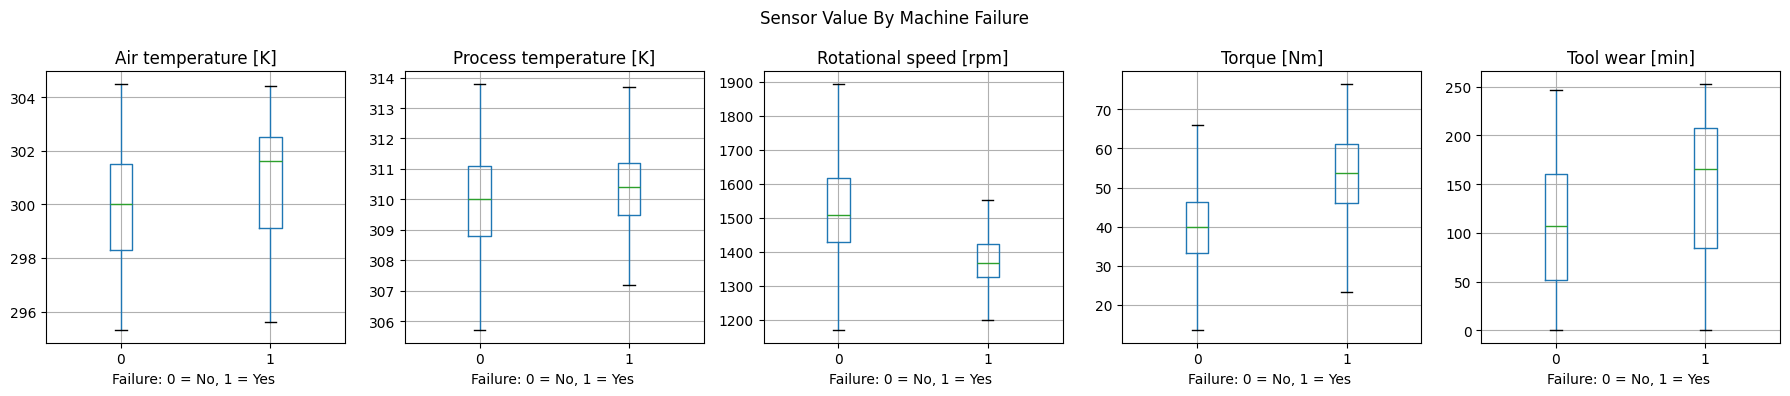

In [ ]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
fig, axes = plt.subplots(1, 5, figsize = (18, 4))
for ax, col in zip(axes, sensor_cols):
  df.boxplot(column = col, by = "Machine failure", ax = ax, showfliers = False)
  ax.set_title(col)
  ax.set_xlabel("Failure: 0 = No, 1 = Yes ")
fig.suptitle("Sensor Value By Machine Failure")
plt.tight_layout()
plt.show()

In [18]:
print("Duplicate rows:", df.duplicated().sum())

print("\nColumn data types:")
print(df.dtypes)

Duplicate rows: 0

Column data types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [20]:
columns_to_exclude = [
    "UDI", "Product ID",
    "TWF","HDF","PWF","OSF","RNF"
]
X = df.drop(columns=columns_to_exclude + ["Machine failure"])
y = df["Machine failure"]
print("Input features:", X.columns.tolist())
print("Target counts:")
print(y.value_counts())

Input features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Target counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [21]:
X = X.copy()

X["Temperature difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

X["Estimated power [W]"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)
)

X["Torque x tool wear"] = (
    df["Torque [Nm]"] * df["Tool wear [min]"]
)

print("Feature table shape:", X.shape)
display(X.head())


Feature table shape: (10000, 9)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference [K],Estimated power [W],Torque x tool wear
0,M,298.1,308.6,1551,42.8,0,10.5,6951.590560,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,6826.722724,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,7749.387543,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,5927.504659,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,5897.816608,360.0
